In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import keras
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from keras.utils import to_categorical
from keras.layers import Flatten, Dense, Conv2D, MaxPooling2D
from keras.models import Sequential
import matplotlib.pyplot as plt

In [6]:
from PIL import Image
from glob import glob

In [17]:
images_train_cat = glob("D:/csv/training_set/training_set/cats/*.jpg")
images_train_dog = glob("D:/csv/training_set/training_set/dogs/*.jpg")
images_test_cat = glob("D:/csv/test_set/test_set/cats/*.jpg")
images_test_dog = glob("D:/csv/test_set/test_set/dogs/*.jpg")

In [55]:
x_train , y_train = [], []
for images in range(len(images_train_cat)):
    im = Image.open(images_train_cat[images])
    im = im.convert('RGB')
    im = im.resize((128, 128))
    im = np.array(im)
    x_train.append(im)
    y_train.append(0)
for images in range(len(images_train_dog)):
    im = Image.open(images_train_dog[images])
    im = im.convert('RGB')
    im = im.resize((128, 128))
    im = np.array(im)
    x_train.append(im)
    y_train.append(1)

In [57]:
x_test, y_test = [], []
for images in range(len(images_test_cat)):
    im = Image.open(images_test_cat[images])
    im = im.convert('RGB')
    im = im.resize((128, 128))
    im = np.array(im)
    x_test.append(im)
    y_test.append(0)
for images in range(len(images_test_dog)):
    im = Image.open(images_test_dog[images])
    im = im.convert('RGB')
    im = im.resize((128, 128))
    im = np.array(im)
    x_test.append(im)
    y_test.append(1)

In [58]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

In [61]:
print(x_train.shape, x_train.dtype)
print(y_train.shape, y_train.dtype)
print(x_test.shape, x_test.dtype)
print(y_test.shape, y_test.dtype)

(8005, 128, 128, 3) uint8
(8005,) int64
(2023, 128, 128, 3) uint8
(2023,) int64


In [66]:
x_train = x_train[:8000].astype('float32') / 255
y_train = y_train[:8000]
x_test = x_test[:2000].astype('float32') / 255
y_test = y_test[:2000]

In [122]:
print(x_train.shape, x_train.dtype)
print(y_train.shape, y_train.dtype)
print(x_test.shape, x_test.dtype)
print(y_test.shape, y_test.dtype)

(8000, 128, 128, 3) float32
(8000,) int64
(2000, 128, 128, 3) float32
(2000,) int64


In [ ]:
# cotici 0 , dogi 1

In [216]:
class modelkeras:
    def __init__(self):
        self.model = None
        self.earstopping = None
        self.result__train_accuracy = None
        self.result_train_loss = None
        self.result_test_accuracy = None
        self.result_test_loss = None

    def modelbuilding(self):
        model = keras.Sequential([
            keras.layers.Input(shape = (128, 128, 3)),
            keras.layers.Conv2D(filters = 16, kernel_size = (3 ,3), padding = 'same', activation = 'relu', strides = 3),
            keras.layers.MaxPooling2D(pool_size = (2 ,2)),
            keras.layers.Conv2D(filters = 32, kernel_size = (2, 2), activation = 'relu', strides = 2 ),
            keras.layers.MaxPooling2D(pool_size = (2, 2)),
            keras.layers.Conv2D(filters = 64, kernel_size = (2, 2), activation = 'relu', strides = 2 ),
            keras.layers.Flatten(),
            keras.layers.Dense(64, activation = 'relu', kernel_regularizer = regularizers.L2(0.001)),
            keras.layers.Dense(32),
            keras.layers.Dense(1, activation = 'sigmoid')
        ])
        model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
        self.model = model

    def stopping(self):
        stopping_ = EarlyStopping(
            monitor = 'accuracy',
            min_delta = 0,
            patience = 4,     
            verbose = 1,
            mode = 'max',
            restore_best_weights= True
        )
        self.earstopping = stopping_

    def modelfit(self, images, labels, batch, nepoch):
        self.model.fit(images, labels, batch_size = batch, epochs = nepoch, verbose = 0, callbacks = [self.earstopping])
        return print('Done')

    def train_evaluate(self, xtrain, ytrain):
        train_loss, train_accuracy = self.model.evaluate(xtrain, ytrain, verbose = 0)
        self.result_train_accuracy = train_accuracy
        self.result_train_loss = train_loss
        return print(f'Тренировочная ошибка: {train_loss}, Тренировочная точность: {train_accuracy}')

    def test_evaluate(self, xtest, ytest):
        test_loss, test_accuracy = self.model.evaluate(xtest, ytest, verbose = 0)
        self.result_test_accuracy = test_accuracy
        self.result_test_loss = test_loss
        return print(f'Тестовая ошибка: {test_loss}, Тестовая точность: {test_accuracy}')

    def model_result(self):
        print(f'Результат точности тренировочной и  тестовой прогонки : {self.result_train_accuracy:.4f} / {self.result_test_accuracy:.4f} ')
        print(f'Результат ошибки тренировочной и тестовой прогонки: {self.result_train_loss:.4f} / {self.result_test_loss:.4f}')

    def model_predict(self, xtrain):
        n = 10
        qwer = len(xtrain)
        rand = np.random.choice(qwer, size=n, replace=False)
        images = xtrain[rand]
        name = ['cat', 'dog']
        pred = self.model.predict(images)
        class_pred = np.argmax(pred, axis = 1)
        result = np.max(pred, axis = 1)
        plt.figure(figsize = (9,9))
        for i in range(n):
            plt.subplot(2, n ,i+1)
            plt.imshow(images[i])
            plt.title(name[class_pred[i]])
            plt.axis('off')
        plt.tight_layout()
        plt.show()


In [221]:
kerasclass = modelkeras()
kerasclass.modelbuilding()
kerasclass.stopping()

In [222]:
kerasclass.modelfit(x_train, y_train, 64, 10)

Restoring model weights from the end of the best epoch: 9.
Done


In [219]:
kerasclass.train_evaluate(x_train, y_train)

Тренировочная ошибка: 0.45701366662979126, Тренировочная точность: 0.7953749895095825


In [220]:
kerasclass.test_evaluate(x_test, y_test)

Тестовая ошибка: 0.58900386095047, Тестовая точность: 0.7049999833106995


In [214]:
kerasclass.model_result()

Результат точности тренировочной и  тестовой прогонки : 0.8112 / 0.7150 
Результат ошибки тренировочной и тестовой прогонки: 0.4479 / 0.6003


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


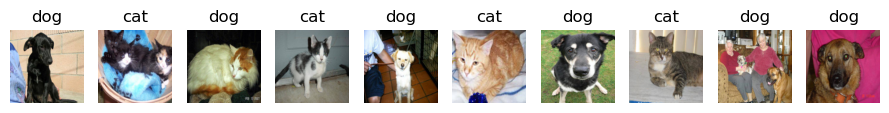

In [208]:
kerasclass.model_predict(x_train)